In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import synphot.units
from dask.config import collect
from more_itertools.more import collapse
from synphot import Observation

from hispecfib.lightpath import *
import hispecfib.throughput_helper as th
import astropy.units as u

excel = '/Users/jibailey/src/hispec-fib/hispecfib/HISPEC_throughputs.xlsx'
data_dir = '/Users/jibailey/Library/CloudStorage/OneDrive-CaliforniaInstituteofTechnology/HISPEC/HISPEC - Systems Engineering [L2]/HISPEC - Performance Budgets/Optical transmission budget/Excel Throughput Code/inputs'

Excluding row 49 due to 'qe' in Name qe.


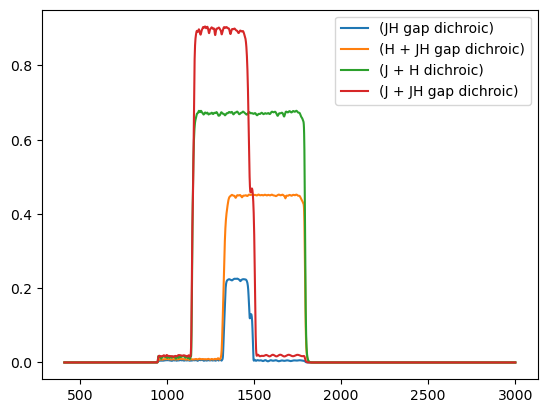

In [2]:
ab_trans=th.section_transmissions(excel, path_to_data=data_dir)
ATC_MODE_TRANS = th.section_transmissions(excel, 'FEI ATC', exclude='QE', all_modes=True, path_to_data=data_dir)
for i,(k,(w,t)) in enumerate(ATC_MODE_TRANS.items()):
    plt.plot(w,t*(i+1)/4,label=k)
plt.legend()

In [3]:
AO_PREOPTIC_TRANS = th.section_transmissions(excel, 'AO', path_to_data=data_dir)
FEI_PREOPTIC_TRANS = th.section_transmissions(excel, 'FEI COMMON', path_to_data=data_dir)

ATC_MODE_TRANS = th.section_transmissions(excel, 'FEI ATC', exclude='QE', all_modes=True, path_to_data=data_dir)

ATC_TRANS_NO_DICH = th.section_transmissions(excel, 'FEI ATC', exclude=['QE', 'ATC Dichroic'], path_to_data=data_dir)
ATC_DICH_REFLECTION = th.section_transmissions(excel, 'FEI ATC', names=['ATC Dichroic'], all_modes=True, path_to_data=data_dir)
ATC_AR = th.section_transmissions(excel, 'FEI BLUE', path_to_data=data_dir, names=['ATC Dichroic AR Coating'])

ATC_DICH_TRANSMISSION_AND_AR = th.section_transmissions(excel, 'FEI BLUE', names=['ATC Dichroic', 'ATC Dichroic AR Coating'],
                                                        all_modes=True, path_to_data=data_dir)
FEI_YJ_TRANS_PIAA_ONLY = th.section_transmissions(excel, 'FEI BLUE', names=['PIAA Lenses', 'PIAA AR Coating Surf 1',
                                                                            'PIAA AR Coating Surf 2', 'PIAA AR Coating Surf 3',
                                                                            'PIAA AR Coating Surf 4'], path_to_data=data_dir)
FEI_YJ_TRANS_NPIAA_NATC = th.section_transmissions(excel, 'FEI BLUE', exclude=['PIAA', 'atc'], path_to_data=data_dir)


FEI_HK_TRANS_PIAA_ONLY = th.section_transmissions(excel, 'FEI RED', names=['PIAA Lenses', 'PIAA AR Coating Surf 1',
                                                                           'PIAA AR Coating Surf 2', 'PIAA AR Coating Surf 3',
                                                                           'PIAA AR Coating Surf 4'], path_to_data=data_dir)
FEI_HK_TRANS_NPIAA_NATC = th.section_transmissions(excel, 'FEI RED', exclude=['PIAA', 'atc'], path_to_data=data_dir)


x = th.make_common_grid([ATC_AR, ATC_DICH_REFLECTION, ATC_DICH_TRANSMISSION_AND_AR, ATC_TRANS_NO_DICH])
ATC_AR, ATC_DICH_REFLECTION, ATC_DICH_TRANSMISSION_AND_AR, ATC_TRANS_NO_DICH = x

# ATC Dichroic and on to ATC, backwards after CSD
RETRO = 1
ATC_REVERSE_MODE_TRANS = {}
ATC_REVERSE_GHOST_MODE_TRANS = {}
ATC_COMBINED_REVERSE_MODE_TRANS = {}
wl_grid = ATC_AR[0]
for k in ATC_DICH_TRANSMISSION_AND_AR:
    #YJ&HK: atc_ar_trans**2 * atc_dich_refl * retro * atc_ar_trans * ATC_dich_tras * rest_of_atc_chain
    net_trans = ATC_AR[1]**2*ATC_DICH_REFLECTION[k][1]*RETRO*ATC_DICH_TRANSMISSION_AND_AR[k][1]*ATC_TRANS_NO_DICH[1]
    ATC_REVERSE_MODE_TRANS[k] = wl_grid, net_trans

    #HK&YJ: atc_ar_refl * retro * atc_ar_trans * ATC_dich_tras * rest_of_atc_chain
    net_trans_ghost = (1-ATC_AR[1])*RETRO*ATC_DICH_TRANSMISSION_AND_AR[k][1]*ATC_TRANS_NO_DICH[1]
    ATC_REVERSE_GHOST_MODE_TRANS[k] = wl_grid, net_trans_ghost  # Ghost doesn't see in reflection
    ATC_COMBINED_REVERSE_MODE_TRANS[k] = wl_grid, (net_trans_ghost+net_trans).clip(0,1)


# FOCUS_COUPLING = th.section_transmissions(excel, 'COUPLING PERFECT', path_to_data=data_dir)

OFS_FIBER = th.section_transmissions(excel, 'FIBER TRANSMISSION BLUE', path_to_data=data_dir)
ZBLAN_FIBER = th.section_transmissions(excel, 'FIBER TRANSMISSION RED', path_to_data=data_dir)

OFS_FIBER_TIB = th.section_transmissions(excel, 'TIB NAS TRANSMISSION BLUE', path_to_data=data_dir, force_include=True)
ZBLAN_FIBER_TIB = th.section_transmissions(excel, 'TIB NAS TRANSMISSION RED', path_to_data=data_dir, force_include=True)

BSPEC_TC = th.section_transmissions(excel, 'BSPEC', exclude='QE', path_to_data=data_dir)
RSPEC_TC = th.section_transmissions(excel, 'RSPEC', exclude='QE', path_to_data=data_dir)

Excluding row 49 due to 'qe' in Name qe.
Excluding row 43 due to 'atc dichroic' in Name atc dichroic.
Excluding row 49 due to 'qe' in Name qe.
Excluding row 51 due to 'atc' in Name atc dichroic.
Excluding row 52 due to 'atc' in Name atc dichroic ar coating.
Excluding row 54 due to 'piaa' in Name piaa lenses.
Excluding row 55 due to 'piaa' in Name piaa ar coating surf 1.
Excluding row 56 due to 'piaa' in Name piaa ar coating surf 2.
Excluding row 57 due to 'piaa' in Name piaa ar coating surf 3.
Excluding row 58 due to 'piaa' in Name piaa ar coating surf 4.
Excluding row 69 due to 'atc' in Name atc dichroic.
Excluding row 70 due to 'atc' in Name atc dichroic ar coating.
Excluding row 73 due to 'piaa' in Name piaa lenses.
Excluding row 74 due to 'piaa' in Name piaa ar coating surf 1.
Excluding row 75 due to 'piaa' in Name piaa ar coating surf 2.
Excluding row 76 due to 'piaa' in Name piaa ar coating surf 3.
Excluding row 77 due to 'piaa' in Name piaa ar coating surf 4.
Excluding row 122 d

In [4]:
def db2trans(db):
    return 10**-(db/10)

FREESPACE_COUPLING = .75

POWER_SPLITTER_OUTPUT_FRACTION = (.2485+.2533+.2533+.2449)/4
SMF_2_MMF_COUPLING = .8

WDM_YJ_PS1_TRANS = ([900, 1028, 1270, 1430, 1510, 2330, 2600],
                    [.3,
                     db2trans((5.23+4.83+6.35+4.22)/4),
                     db2trans((6.90+6.55+6.38+7.03)/4),
                     db2trans((6.46+6.37+6.26+6.58)/4),
                     db2trans((6.41+6.46+6.53+6.63)/4),
                     db2trans((9.67+15.21+15.20+19.78)/4),
                     0])


## Placeholder
WDM_HK_TRANS = ([900, 1028, 1270, 1430, 1510, 2330, 2600],
                [.3*.9,
                 db2trans((5.23+4.83+6.35+4.22)/4)*.9,
                 db2trans((6.90+6.55+6.38+7.03)/4)*.9,
                 db2trans((6.46+6.37+6.26+6.58)/4)*.9,
                 db2trans((6.41+6.46+6.53+6.63)/4)*.9,
                 0.05,
                 0])

lp = build_hispec_partial()

# Fiber transmissions and couplings
lp.get('fib_yj_retro').transmission = TransmissionCurve.from_tabulated(*OFS_FIBER_TIB)
lp.get('fib_yj_retro').coupling = FREESPACE_COUPLING*POWER_SPLITTER_OUTPUT_FRACTION
lp.get('fib_yj_smf_pd').transmission = TransmissionCurve.from_tabulated(*OFS_FIBER_TIB)
lp.get('fib_yj_smf_pd').coupling = FREESPACE_COUPLING*SMF_2_MMF_COUPLING
lp.get('fib_yj_ao').transmission = TransmissionCurve.from_tabulated(*OFS_FIBER_TIB)
lp.get('fib_yj_ao').coupling = FREESPACE_COUPLING
lp.get('fib_yj_fei').transmission = TransmissionCurve.from_tabulated(*OFS_FIBER_TIB)
lp.get('fib_yj_fei').coupling = FREESPACE_COUPLING
lp.get('fib_yj_science').transmission = TransmissionCurve.from_tabulated(*OFS_FIBER)
lp.get('fib_yj_science').coupling = FREESPACE_COUPLING

lp.get('fib_hk_retro').transmission = TransmissionCurve.from_tabulated(*ZBLAN_FIBER_TIB)
lp.get('fib_hk_retro').coupling = FREESPACE_COUPLING*POWER_SPLITTER_OUTPUT_FRACTION
lp.get('fib_hk_smf_pd').transmission = TransmissionCurve.from_tabulated(*ZBLAN_FIBER_TIB)
lp.get('fib_hk_smf_pd').coupling = FREESPACE_COUPLING*SMF_2_MMF_COUPLING
lp.get('fib_hk_ao').transmission = TransmissionCurve.from_tabulated(*ZBLAN_FIBER_TIB)
lp.get('fib_hk_ao').coupling = FREESPACE_COUPLING
lp.get('fib_hk_fei').transmission = TransmissionCurve.from_tabulated(*ZBLAN_FIBER_TIB)
lp.get('fib_hk_fei').coupling = FREESPACE_COUPLING
lp.get('fib_hk_science').transmission = TransmissionCurve.from_tabulated(*ZBLAN_FIBER)
lp.get('fib_hk_science').coupling = FREESPACE_COUPLING

lp.get('jumper_1028').coupling = db2trans(1.42)
lp.get('jumper_1270').coupling = db2trans(0.56)
lp.get('jumper_1430_yj').coupling = db2trans(.39)
lp.get('jumper_1510').coupling = db2trans(4.36)
lp.get('jumper_2330').coupling = db2trans(5.13)
lp.get('jumper_1430_hk').coupling = db2trans(3.3)

# Pre ATC Dichroic Losses
lp.get('ao_losses').t_AB = TransmissionCurve.from_tabulated(*AO_PREOPTIC_TRANS)
lp.get('fei_pre_losses').t_AB = TransmissionCurve.from_tabulated(*FEI_PREOPTIC_TRANS)

# ATC Dichroic and on to ATC, forward
lp.get('atc_dichroic_selector')._models['JHgap'][('A','B')] = TransmissionCurve.from_tabulated(*ATC_MODE_TRANS['(JH gap dichroic)'])
lp.get('atc_dichroic_selector')._models['JH'][('A','B')] = TransmissionCurve.from_tabulated(*ATC_MODE_TRANS['(J + H dichroic)'])
lp.get('atc_dichroic_selector')._models['H'][('A','B')] = TransmissionCurve.from_tabulated(*ATC_MODE_TRANS['(H + JH gap dichroic)'])
lp.get('atc_dichroic_selector')._models['J'][('A','B')] = TransmissionCurve.from_tabulated(*ATC_MODE_TRANS['(J + JH gap dichroic)'])

# ATC Dichroic to CSD, forward
lp.get('atc_dichroic_selector')._models['JHgap'][('A','C')] = TransmissionCurve.from_tabulated(*ATC_DICH_TRANSMISSION_AND_AR['(JH gap dichroic)'])
lp.get('atc_dichroic_selector')._models['JH'][('A','C')] = TransmissionCurve.from_tabulated(*ATC_DICH_TRANSMISSION_AND_AR['(J + H dichroic)'])
lp.get('atc_dichroic_selector')._models['H'][('A','C')] = TransmissionCurve.from_tabulated(*ATC_DICH_TRANSMISSION_AND_AR['(H + JH gap dichroic)'])
lp.get('atc_dichroic_selector')._models['J'][('A','C')] = TransmissionCurve.from_tabulated(*ATC_DICH_TRANSMISSION_AND_AR['(J + JH gap dichroic)'])

# ATC Dichroic and on to ATC, backwards after CSD
lp.get('atc_dichroic_selector')._models['JHgap'][('C','B')] = TransmissionCurve.from_tabulated(*ATC_COMBINED_REVERSE_MODE_TRANS['(JH gap dichroic)'])
lp.get('atc_dichroic_selector')._models['JH'][('C','B')] = TransmissionCurve.from_tabulated(*ATC_COMBINED_REVERSE_MODE_TRANS['(J + H dichroic)'])
lp.get('atc_dichroic_selector')._models['H'][('C','B')] = TransmissionCurve.from_tabulated(*ATC_COMBINED_REVERSE_MODE_TRANS['(H + JH gap dichroic)'])
lp.get('atc_dichroic_selector')._models['J'][('C','B')] = TransmissionCurve.from_tabulated(*ATC_COMBINED_REVERSE_MODE_TRANS['(J + JH gap dichroic)'])

# CSD and on to foci, excluding piaa or fiber coupling
lp.get('csd').curves[('A','B')] = TransmissionCurve.from_tabulated(*FEI_YJ_TRANS_NPIAA_NATC)
lp.get('csd').curves[('A','C')] = TransmissionCurve.from_tabulated(*FEI_HK_TRANS_NPIAA_NATC)
lp.get('csd').curves[('B','A')] = TransmissionCurve.from_tabulated(*FEI_YJ_TRANS_NPIAA_NATC)
lp.get('csd').curves[('C','A')] = TransmissionCurve.from_tabulated(*FEI_HK_TRANS_NPIAA_NATC)

lp.get('selector_yj_piaa')._models['piaa'] = {("A", "B"):TransmissionCurve.from_tabulated(*FEI_YJ_TRANS_PIAA_ONLY)}
lp.get('selector_hk_piaa')._models['piaa'] = {("A", "B"):TransmissionCurve.from_tabulated(*FEI_HK_TRANS_PIAA_ONLY)}

# TIB Components
lp.get('wdm_yj').per_input = 3*[TransmissionCurve.from_tabulated(*WDM_YJ_PS1_TRANS)]
lp.get('wdm_hk').per_input = 3*[TransmissionCurve.from_tabulated(*WDM_HK_TRANS)]

In [5]:
s_1028 = lp.get("LD1028")
s_1270 = lp.get("LD1270")
s_1430_yj = lp.get("LD1430_yj")
s_1430_hk = lp.get("LD1430_hk")
s_1510 = lp.get("LD1510")
s_2330 = lp.get("LD2330")

atc = lp.get("ATC")
rspec = lp.get("RSPEC")
bspec = lp.get("BSPEC")

pd_yj = lp.get("pd_yj")
pd_hk = lp.get("pd_hk")

att_1028 = lp.get("att_1028")
att_1270 = lp.get("att_1270")
att_1430_yj = lp.get("att_1430_yj")
att_1430_hk = lp.get("att_1430_hk")
att_1510 = lp.get("att_1510")
att_2330 = lp.get("att_2330")

In [6]:
# att_1028.set_db(73)
# att_1270.set_db(40)
# att_1430_yj.set_db(90)
# att_1430_hk.set_db(90)
# att_1510.set_db(33)
# att_2330.set_db(0)
#
# lp.get("atc_dichroic_selector").set_state("JHgap")
# lp.get("selector_yj_focus").set_state("SMF")
# lp.get("selector_hk_focus").set_state("MMF")
#
# # Retro switch (YJ): 1‑in → 2‑out
# lp.get("sw21_yj_retro").set_state('C','A')  # CA:Forward CB:Retro
#
# # FEI feed switch: 1→2
# lp.get("sw25_yj_fei").set_state('C','B')  # CA: AO CB: FEI
#
# # PD branch: 2→1
# lp.get("sw27_yj_pd").set_state('A','C')  #AC: SMF BC: MMF
# x = lp.find_all_paths(s_1430_yj.port("out"), pd_yj.port("in"))
# pc  = lp.path_curve(x[0])
#
# ss=SourceSpectrum(synmodels.Gaussian1D, amplitude=6.583412854219877e+20, mean=1430.024*u.nm, stddev=5.79326831967524e-06*u.nm)
# samp_wave = np.arange(1425,1435, 5e-6)*u.nm
# print((ss(samp_wave)[:-1]*u.cm**2*np.diff(samp_wave)).to('ph/s').sum())
# spectra = lp.propagate({s_1430_yj.port("out"): s_1430_yj.spectrum()}, [pd_yj, pd_hk, atc])
# s = spectra[pd_yj]
# ss = s.ss
# samp_wave = np.arange(1425,1435,5e-6)*u.nm
# print((ss(samp_wave)[:-1]*u.cm**2*np.diff(samp_wave)).to('ph/s').sum())
# watts = (spectra[pd_yj](samp_wave, photons=True)*(const.h * const.c / (samp_wave).to(u.m))/u.s).to('fW')
# print(watts.max())
# print(pd_yj.observe(spectra[pd_yj], grid_nm=np.arange(1425,1435,spectra[pd_yj].width_hint_nm.value), texp_s=1).signal)

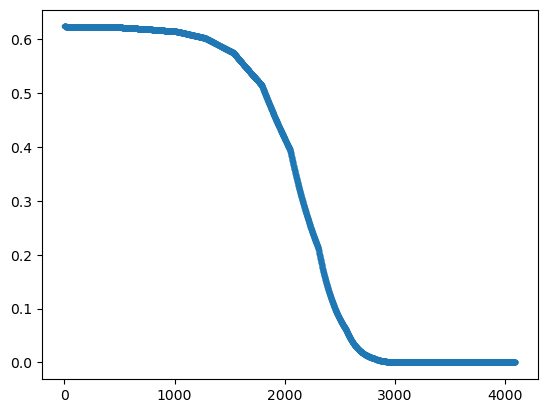

In [7]:
v = np.array([0, 0.5, 0.75, 1, 1.25, 1.5, 1.75, 2, 2.25, 2.5, 2.75, 3, 3.25])

atten= np.array([[3.49, 3.49, 3.50, 3.50, 3.54, 3.65, 3.98, 4.70, 6.40, 10.62, 19.48, 33.63, 46.855],
                 [1.17, 1.19, 1.21, 1.24, 1.33, 1.53, 2.04, 3.27, 6.19, 12.04, 21.89, 36.26, 46.855],
                 [0.72, 0.73, 0.75, 0.79, 0.89, 1.12, 1.68, 2.97, 5.92, 11.68, 20.82, 32.94, 48.10],
                 [0.50, 0.51, 0.54, 0.58, 0.69, 0.93, 1.47, 2.77, 5.71, 11.35, 20.31, 31.96, 45.61],
                 [4.38, 4.40, 4.44, 4.48, 4.57, 4.80, 5.25, 6.44, 9.36, 15.29, 24.14, 45.53, 46.855]
                ]).mean(0)
dac2volt = lambda x: x*4/4096
volt2atten = scipy.interpolate.interp1d(v, atten, kind='linear', bounds_error=False, fill_value=(0, 48))
plt.plot(list(range(4096)), db2trans(volt2atten(dac2volt(np.array(list(range(4096)))))),'.')

In [8]:
def result_summary(obs):

    # 4-panel summary: Left column YJ/B, Right column HK/R. ATC on the top row.
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))


    def show_no_data(ax, title):
        ax.text(0.5, 0.5, "No data", ha='center', va='center', fontsize=14, color='gray')
        ax.set_title(title)
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)


    # Top-left: ATC (YJ/B)
    ax = axes[0, 0]
    if 'atc' in globals() and isinstance(obs.get(atc, None), type(obs.get(next(iter(obs.keys())), None))):
        data = getattr(obs.get(atc, None), 'snr', None)
        if data is not None:
            im0 = ax.imshow(data)
            ax.set_title('ATC (YJ/B) S/N')
            plt.colorbar(im0, ax=ax, fraction=0.046, pad=0.04)
        else:
            show_no_data(ax, 'ATC (YJ/B) S/N')
    else:
        show_no_data(ax, 'ATC (YJ/B) S/N')

    # Top-right: ATC (HK/R) — using same ATC data as a template if available
    ax = axes[0, 1]
    if 'atc' in globals() and isinstance(obs.get(atc, None), type(obs.get(next(iter(obs.keys())), None))):
        data = getattr(obs.get(atc, None), 'snr', None)
        if data is not None:
            im1 = ax.imshow(data)
            ax.set_title('ATC (HK/R) S/N')
            plt.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)
        else:
            show_no_data(ax, 'ATC (HK/R) S/N')
    else:
        show_no_data(ax, 'ATC (HK/R) S/N')

    # Bottom-left: BSPEC S/N (YJ/B)
    ax = axes[1, 0]
    bs_data = obs.get(bspec, None) if 'bspec' in globals() else None
    if isinstance(bs_data, dict) and len(bs_data) > 0:
        for k, v in bs_data.items():
            if hasattr(v, 'sn'):
                ax.plot(v.sn(), label=f'Order: {k}')
        ax.set_title('BSPEC S/N (YJ/B)')
        ax.set_xlabel('Pixel / Sample')
        ax.set_ylabel('S/N')
        if len(ax.lines) > 0:
            ax.legend(fontsize=8)
        else:
            show_no_data(ax, 'BSPEC S/N (YJ/B)')
    else:
        show_no_data(ax, 'BSPEC S/N (YJ/B)')

    # Bottom-right: RSPEC S/N (HK/R)
    ax = axes[1, 1]
    rs_data = obs.get(rspec, None) if 'rspec' in globals() else None
    if isinstance(rs_data, dict) and len(rs_data) > 0:
        for k, v in rs_data.items():
            if hasattr(v, 'sn'):
                ax.plot(v.sn(), label=f'Order: {k}')
        ax.set_title('RSPEC S/N (HK/R)')
        ax.set_xlabel('Pixel / Sample')
        ax.set_ylabel('S/N')
        if len(ax.lines) > 0:
            ax.legend(fontsize=8)
        else:
            show_no_data(ax, 'RSPEC S/N (HK/R)')
    else:
        show_no_data(ax, 'RSPEC S/N (HK/R)')

    plt.tight_layout()

    # Photodiode summary: print signal and S/N for YJ and HK
    def _print_pd_summary(label, det):
        d = obs.get(det, None)
        if d is None:
            print(f'{label}: No data')
            return
        print(f'{label} signal: {d.signal:.0f} ± {d.noise:.2f} (S/N: {d.snr:.0f}, sat: {d.saturation:.0f})')


    print('')
    _print_pd_summary('PD YJ', pd_yj)
    _print_pd_summary('PD HK', pd_hk)

{<Photodiode pd_yj>: <hispecfib.lightpath.Spectrum object at 0x324106b90>, <Photodiode pd_hk>: <hispecfib.lightpath.Spectrum object at 0x32637dd10>, <Imager ATC>: <hispecfib.lightpath.Spectrum object at 0x327134750>, <Spectrograph RSPEC>: None, <Spectrograph BSPEC>: None}

PD YJ signal: 1311 ± 8.41 (S/N: 156, sat: 27572)
PD HK signal: 30 ± 2.58 (S/N: 12, sat: 26660)


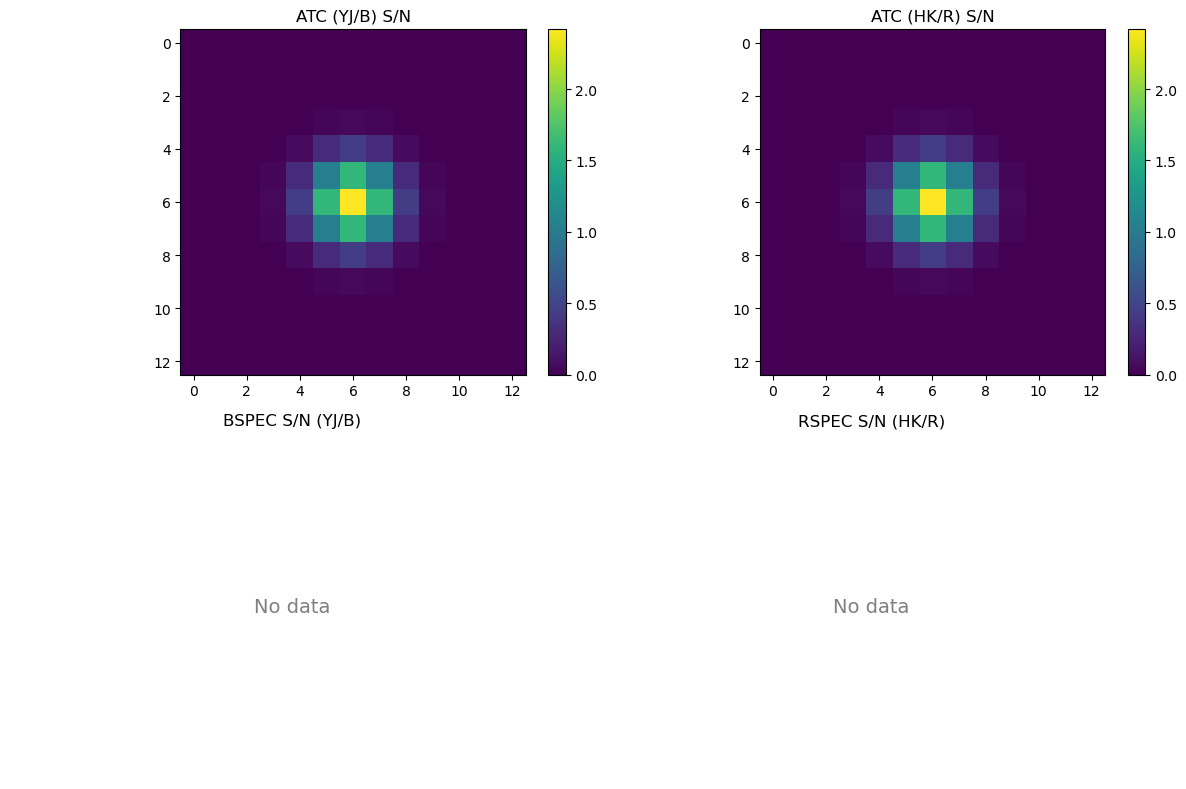

In [9]:
# ### Anticipated Static Attenuation Chains
# - 1028: -90.0 to -73.0 dB, range 17.0 dB, **static -73.0 dB**
# - 1270:  -70.0 to -40.0 dB, range 30.0 dB, **static -40.0 dB**
# - 1430: range 0.0 dB, **static -100.0 dB**
# - 1510: -80.0 to -33.0 dB, range 47.0 dB, **static -33.0 dB**
# - 2330: -73.0 to -3.0 dB, range 70.0 dB, **static -3.0 dB**

att_1028.set_db(73)
att_1270.set_db(40)
att_1430_yj.set_db(90)
att_1430_hk.set_db(90)
att_1510.set_db(33)
att_2330.set_db(3)

lp.get("atc_dichroic_selector").set_state("JHgap")
lp.get("selector_yj_focus").set_state("SMF")  #SMF MMF SCI
lp.get("selector_hk_focus").set_state("SMF")
lp.get('vortex_selector').set_state('null')

# Retro switch (YJ): 1‑in → 2‑out
lp.get("sw21_yj_retro").set_state('CA')  # CA:Forward CB:Retro
lp.get("sw22_hk_retro").set_state('CA')  # CA:Forward CB:Retro

# FEI feed switch: 1→2
lp.get("sw25_yj_fei").set_state('CB')  # CA: AO CB: FEI
lp.get("sw26_hk_fei").set_state('CB')  # CA: AO CB: FEI

# PD branch: 2→1
lp.get("sw27_yj_pd").set_state('AC')  #AC: SMF BC: MMF
lp.get("sw28_hk_pd").set_state('AC')  #AC: SMF BC: MMF

src_map = {
    s_1028.port("out"): s_1028.spectrum(),
    # s_1270.port("out"): s_1270.spectrum(),
    # s_1430_yj.port("out"): s_1430_yj.spectrum(),
    # s_1430_hk.port("out"): s_1430_hk.spectrum(),
    # s_1510.port("out"): s_1510.spectrum(),
    s_2330.port("out"): s_2330.spectrum(),
}
spectra_at_detectors = lp.propagate(src_map, [pd_yj, pd_hk, atc, rspec, bspec])
obs = {}
print(spectra_at_detectors)
for d in spectra_at_detectors:
    spec = spectra_at_detectors[d]
    if spec is None:
        continue
    samp_wave = np.arange(900,2600, spec.width_hint_nm.value)*u.nm
    obs[d]=d.observe(spec, grid_nm=samp_wave, texp_s=.05)

result_summary(obs)
# plt.plot(obs[rspec][62].sn())

In [10]:
@dataclass
class ConfigCrap:
    min_config = None
    max_config = None
    min_trans = 1.0
    max_trans = 0.0
    min_paths = None
    max_paths = None
    min_source = None
    max_source = None
    min_detector = None
    max_detector = None

def config2str(cfg):
    return f'{cfg[1][1]} Vortex {cfg[0][1]}, {cfg[2][1]}, {cfg[3][1]} AO/FEI={cfg[4][1]}'

def find_bounding_configs():

    lp.get("att_1028").set_db(0)
    lp.get("att_1270").set_db(0)
    lp.get("att_1430_yj").set_db(0)
    lp.get("att_1430_hk").set_db(0)
    lp.get("att_1510").set_db(0)
    lp.get("att_2330").set_db(0)

    x={
        'vortex_selector': ("peak","null", "clear"),
        'atc_dichroic_selector': ("JHgap", "H", "J", "JH"),
        ('selector_yj_focus', 'selector_hk_focus'): ("SMF", "MMF", "SCI"),
        ('selector_yj_piaa', 'selector_hk_piaa'): ('piaa', 'clear'),
        ('sw25_yj_fei', 'sw26_hk_fei'): ('CA', 'CB'),
        ("sw21_yj_retro", 'sw22_hk_retro'): ('CA',),  # CA:Forward CB:Retro
        ("sw27_yj_pd", "sw28_hk_pd"): ('AC', 'BC'),  #AC: SMF BC: MMF
    }


    # Find the bounding transmission from through to each detector, find ok levels

    import itertools
    setting_combos = list(itertools.product(*[[(k, vv) for vv in v] for k, v in x.items()]))


    sources = [s_1028, s_1270, s_1430_yj, s_1430_hk, s_1510, s_2330]
    detectors = [atc, pd_yj, pd_hk, rspec, bspec]
    out: Dict[(Source, Detector), ConfigCrap] = {}

    for detector in detectors:
        for source in sources:
            for setting_combo in setting_combos:
                print(f'Checking {config2str(setting_combo)} from {source.name} to {detector.name}...')

                for setting, value in setting_combo:
                    setting = (setting,) if isinstance(setting, str) else setting
                    for s in setting:
                        lp.get(s).set_state(value)

                tcs = [lp.path_curve(path) for path in lp.find_all_paths(source.port('out'),  detector.port('in'))]
                if not tcs:
                    print(f'...No path.')
                    continue

                trans = max([t(source._lambda0.value) for t in tcs])

                current = out.get((source, detector),ConfigCrap())

                if current.min_trans>=trans:
                    print(f'...New min: {trans}')
                    current.min_config=setting_combo
                    current.min_trans=trans
                    current.min_paths=tcs
                    current.min_source=source
                    current.min_detector=detector
                if current.max_trans<=trans:
                    print(f'...New max: {trans}')
                    current.max_config=setting_combo
                    current.max_trans=trans
                    current.max_paths=tcs
                    current.max_source=source
                    current.max_detector=detector

                out[(source, detector)] = current

    return out

In [11]:
def find_nonsat_atten(source, start_db=100):
    lp.get("att_1028").set_db(0)
    lp.get("att_1270").set_db(0)
    lp.get("att_1430_yj").set_db(0)
    lp.get("att_1430_hk").set_db(0)
    lp.get("att_1510").set_db(0)
    lp.get("att_2330").set_db(0)

    source.set_current(source.threshold_current)
    spec = lp.propagate({source.port("out"): source.spectrum()}, [pd_yj, pd_hk, atc, rspec, bspec])

    for d in list(spec.keys()):
        if spec[d] is None:
            del spec[d]
            continue

        samp_wave = np.arange(900, 2600, spec[d].width_hint_nm.value) * u.nm

        # Start high; adapt step only on direction reversals
        db = start_db
        step = 10.0
        min_db, max_db = 0.0, max(120.0, start_db)
        max_iter = 20

        best_db = None
        best_sn = None

        last_dir = 0  # +1 means increase attenuation (higher dB), -1 means decrease attenuation
        for _ in range(max_iter):
            obs = d.observe(spec[d] * TransmissionCurve.constant(db2trans(db)), grid_nm=samp_wave, texp_s=.05)

            if obs is None:
                break
            if isinstance(obs, dict):
                obs = list(obs.values())
                assert len(obs) == 1
                obs = obs[0]

            sn = obs.sn(collapse=np.sum, axis=None)

            # Check conditions
            if np.isfinite(sn) and sn >= 3.0:
                best_db = db
                best_sn = sn
                best_obs = obs
                print(f'{source.name}: S/N={sn:.1f} @ {db:.1f} dB on {d.name}')
                break

            # Decide direction
            if not np.isfinite(sn):
                # Too high (saturated): increase attenuation
                direction = +1
            elif sn < 3.0:
                # Too low: decrease attenuation
                direction = -1
            else:
                direction = 0  # Fallback, though we covered all cases

            # Only shrink step when direction reverses; keep it if consistent
            if last_dir != 0 and direction != 0 and direction != last_dir:
                step = max(step * 0.5, 1)

            # Apply move
            db += direction * step

            # Clamp
            db = float(np.clip(db, min_db, max_db))

            last_dir = direction

        if obs is None:
            del spec[d]
            continue

        # If we never hit the sweet spot, record the last evaluated values
        if best_db is None:
            best_db = db
            best_sn = sn
            best_obs = obs

        spec[d] = (best_sn, best_db, best_obs)

    return spec


In [12]:
def gather_atten_data(out):
    import pandas as pd

    sn_dfs, db_dfs = {}, {}

    for state, source_data in out.items():
        cfg_key = ' '.join(map('='.join, state))
        sn_df, db_df = pd.DataFrame(), pd.DataFrame()

        for source, sd in source_data.items():
            sn_col_data, db_col_data = {}, {}
            for d, (best_sn, best_db, best_obs) in sd.items():
                sn_col_data[d.name] = best_sn
                db_col_data[d.name] = best_db

            for n in ('ATC', 'RSPEC', 'BSPEC', 'pd_yj', 'pd_hk'):
                if n not in sn_col_data:
                    sn_col_data[n] = np.nan
                    db_col_data[n] = np.nan

            sn_df[source.name] = pd.Series(sn_col_data)
            db_df[source.name] = pd.Series(db_col_data)
        sn_dfs[cfg_key] = sn_df
        db_dfs[cfg_key] = db_df

    sn_3d = pd.concat(sn_dfs, axis=1)
    db_3d = pd.concat(db_dfs, axis=1)

    # Robustly fetch the source level as the last columns level (independent of how many config levels there are)
    sources_lvl = db_3d.columns.get_level_values(-1).unique()
    detectors_idx = db_3d.index

    db_values_by_pair = {}
    records = []
    for src in sources_lvl:
        sub = db_3d.xs(src, level=-1, axis=1)  # detectors x configs
        for det in detectors_idx:
            vals = sub.loc[det].dropna().unique().tolist()
            vals_sorted = sorted(vals)
            db_values_by_pair[(src, det)] = set(vals_sorted)
            records.append({'source': src, 'detector': det, 'db_values': tuple(vals_sorted)})

    db_values_df = pd.DataFrame(records)
    display(db_values_df)

    # For each source, print the set of db_values aggregated across all detectors
    for src, grp in db_values_df.groupby('source'):
        agg = set()
        for t in grp['db_values']:
            agg.update(t)
        print(f'{src}: {agg}')

    return db_values_df, sn_3d, db_3d


# Find attens for all dichroics

Low:
- AO+null+dichroics+piaa+SMF/SCI
- AO+peak+dichroics+piaa+SMF/SCI

HIGH:
- FEI+clear+dichroics+clear+MMF/SCI


In [13]:
minima = [{'vortex_selector': vortex,
          'atc_dichroic_selector': dich,
          'lightpath':path,
          'selector_yj_piaa': 'piaa',
          'selector_hk_piaa': 'piaa',
          'sw21_yj_retro': 'CA', # CA:Forward CB:Retro
          'sw22_hk_retro': 'CA',
          'sw25_yj_fei': 'CA', #CA: AO CB: FEI
          'sw26_hk_fei': 'CA'} for dich in ("JHgap", "H", "J", "JH") for vortex in ("null", "peak") for path in ('smf_pd', 'spec')]

maxima = [{'vortex_selector': 'clear',
          'atc_dichroic_selector': dich,
          'lightpath':path,
          'selector_yj_piaa': 'clear',
          'selector_hk_piaa': 'clear',
          'sw21_yj_retro': 'CA', # CA:Forward CB:Retro
          'sw22_hk_retro': 'CA',
          'sw25_yj_fei': 'CB',
          'sw26_hk_fei': 'CB'} for dich in ("JHgap", "H", "J", "JH") for path in ('mmf_pd', 'spec')]

retro = [{'atc_dichroic_selector': dich,
          'lightpath':'retro',
          'selector_yj_piaa': 'clear',
          'selector_hk_piaa': 'clear',
         } for dich in ("JHgap", "H", "J", "JH")]




# Find the bounding transmission from through to each detector, find ok levels
sources = [s_1028, s_1270, s_1430_yj, s_1430_hk, s_1510, s_2330]
out_low: Dict[tuple,dict] = {}
out_high: Dict[tuple,dict] = {}

for state in minima+maxima+retro:
    lp.get("att_1028").set_db(0)
    lp.get("att_1270").set_db(0)
    lp.get("att_1430_yj").set_db(0)
    lp.get("att_1430_hk").set_db(0)
    lp.get("att_1510").set_db(0)
    lp.get("att_2330").set_db(0)
    lp.set_state('meta', state)

    out_high[tuple(state.items())] = {source: find_nonsat_atten(source, start_db=120) for source in sources}

    lp.get("att_1028").set_db(0)
    lp.get("att_1270").set_db(0)
    lp.get("att_1430_yj").set_db(0)
    lp.get("att_1430_hk").set_db(0)
    lp.get("att_1510").set_db(0)
    lp.get("att_2330").set_db(0)
    lp.set_state('meta', state)
    out_low[tuple(state.items())] = {source: find_nonsat_atten(source, start_db=0) for source in sources}


LD1028: S/N=6.4 @ 60.0 dB on pd_yj
LD1028: S/N=4.4 @ 70.0 dB on ATC
LD1270: S/N=13.4 @ 50.0 dB on pd_yj
LD1270: S/N=11.6 @ 60.0 dB on ATC
LD1430_yj: S/N=9.1 @ 30.0 dB on pd_yj
LD1430_yj: S/N=5.6 @ 80.0 dB on ATC
LD1430_hk: S/N=4.1 @ 30.0 dB on pd_yj
LD1430_hk: S/N=20.5 @ 70.0 dB on ATC
LD1510: S/N=7.5 @ 30.0 dB on pd_yj
LD1510: S/N=5.5 @ 10.0 dB on pd_hk
LD1510: S/N=4.5 @ 60.0 dB on ATC
LD2330: S/N=18.1 @ 10.0 dB on pd_yj
LD2330: S/N=13.7 @ 0.0 dB on pd_hk
LD1028: S/N=631.7 @ 40.0 dB on pd_yj
LD1028: S/N=454.0 @ 40.0 dB on ATC
LD1270: S/N=1324.9 @ 30.0 dB on pd_yj
LD1270: S/N=781.6 @ 30.0 dB on ATC
LD1430_yj: S/N=902.6 @ 10.0 dB on pd_yj
LD1430_yj: S/N=517.9 @ 50.0 dB on ATC
LD1430_hk: S/N=405.6 @ 10.0 dB on pd_yj
LD1430_hk: S/N=342.9 @ 50.0 dB on ATC
LD1510: S/N=744.6 @ 10.0 dB on pd_yj
LD1510: S/N=55.3 @ 0.0 dB on pd_hk
LD1510: S/N=459.8 @ 30.0 dB on ATC
LD2330: S/N=181.4 @ 0.0 dB on pd_yj
LD2330: S/N=13.7 @ 0.0 dB on pd_hk
LD1028: S/N=4.4 @ 70.0 dB on ATC
LD1028: S/N=20.4 @ 80.0 dB 

In [25]:
# highest attenuation for which we can get signal in all (min) cases
print('Start at high dB, drop until there is a S/N>3 detection')
x1=gather_atten_data(out_high)[0]
_min_df = x1.assign(min_db=x1['db_values'].apply(lambda t: min(t) if isinstance(t, (list, tuple)) and len(t) > 0 else np.nan))

# lowest attenuation for which we can get avoid saturating in all (max) cases
print('\n\nStart at 0 dB, raise until unsaturated')
x2 = gather_atten_data(out_low)[0]
_max_df = x2.assign(max_db=x2['db_values'].apply(lambda t: max(t) if isinstance(t, (list, tuple)) and len(t) > 0 else np.nan))
for (src, grp_min), (src, grp_max) in zip(_min_df.groupby('source', sort=True), _max_df.groupby('source', sort=True)):
    print(src)
    for (_, min_row), (_, max_row) in zip(grp_min.iterrows(), grp_max.iterrows()):
        assert min_row['detector'] == max_row['detector']
        print(f"- {min_row['detector']},  {min_row['min_db']}-{max_row['max_db']} dB, static: {min(max_row['max_db'], min_row['min_db'])}, range: {abs(max_row['max_db'] - min_row['min_db'])}")
    print()


Start at high dB, drop until there is a S/N>3 detection


,source,detector,db_values
0,LD1028,pd_yj,"(60.0, 90.0, 100.0)"
1,LD1028,pd_hk,"(0.0, 30.0, 40.0)"
2,LD1028,ATC,"(70.0, 100.0, 110.0)"
3,LD1028,RSPEC,()
4,LD1028,BSPEC,"(80.0, 120.0)"
5,LD1270,pd_yj,"(30.0, 50.0, 70.0, 80.0, 90.0, 100.0)"
6,LD1270,pd_hk,"(0.0, 10.0, 20.0, 30.0)"
7,LD1270,ATC,"(60.0, 80.0, 100.0, 110.0, 120.0)"
8,LD1270,RSPEC,()
9,LD1270,BSPEC,"(60.0, 80.0, 90.0, 100.0, 110.0, 120.0)"


LD1028: {0.0, 100.0, 70.0, 40.0, 110.0, 80.0, 120.0, 90.0, 60.0, 30.0}
LD1270: {0.0, 100.0, 70.0, 10.0, 110.0, 80.0, 50.0, 20.0, 120.0, 90.0, 60.0, 30.0}
LD1430_hk: {0.0, 100.0, 70.0, 110.0, 20.0, 120.0, 90.0, 60.0, 30.0}
LD1430_yj: {0.0, 100.0, 70.0, 40.0, 110.0, 80.0, 20.0, 120.0, 60.0, 30.0}
LD1510: {0.0, 100.0, 70.0, 40.0, 10.0, 110.0, 50.0, 20.0, 120.0, 90.0, 60.0, 30.0}
LD2330: {0.0, 100.0, 70.0, 40.0, 10.0, 110.0, 50.0, 60.0}


Start at 0 dB, raise until unsaturated


,source,detector,db_values
0,LD1028,pd_yj,"(40.0, 70.0, 80.0)"
1,LD1028,pd_hk,"(0.0, 20.0)"
2,LD1028,ATC,"(40.0, 70.0, 80.0)"
3,LD1028,RSPEC,()
4,LD1028,BSPEC,"(50.0, 90.0, 100.0)"
5,LD1270,pd_yj,"(10.0, 30.0, 50.0, 60.0, 70.0, 80.0)"
6,LD1270,pd_hk,"(0.0, 10.0)"
7,LD1270,ATC,"(30.0, 50.0, 70.0, 80.0, 90.0)"
8,LD1270,RSPEC,()
9,LD1270,BSPEC,"(30.0, 50.0, 60.0, 70.0, 80.0, 90.0)"


LD1028: {0.0, 100.0, 70.0, 40.0, 80.0, 50.0, 20.0, 90.0}
LD1270: {0.0, 70.0, 10.0, 80.0, 50.0, 90.0, 60.0, 30.0}
LD1430_hk: {0.0, 70.0, 40.0, 10.0, 80.0, 50.0, 90.0}
LD1430_yj: {0.0, 70.0, 40.0, 10.0, 50.0, 90.0, 60.0}
LD1510: {0.0, 70.0, 40.0, 10.0, 80.0, 50.0, 20.0, 90.0, 60.0, 30.0}
LD2330: {0.0, 70.0, 40.0, 10.0, 80.0, 20.0, 30.0}
LD1028
- pd_yj,  60.0-80.0 dB, static: 60.0, range: 20.0
- pd_hk,  0.0-20.0 dB, static: 0.0, range: 20.0
- ATC,  70.0-80.0 dB, static: 70.0, range: 10.0
- RSPEC,  nan-nan dB, static: nan, range: nan
- BSPEC,  80.0-100.0 dB, static: 80.0, range: 20.0

LD1270
- pd_yj,  30.0-80.0 dB, static: 30.0, range: 50.0
- pd_hk,  0.0-10.0 dB, static: 0.0, range: 10.0
- ATC,  60.0-90.0 dB, static: 60.0, range: 30.0
- RSPEC,  nan-nan dB, static: nan, range: nan
- BSPEC,  60.0-90.0 dB, static: 60.0, range: 30.0

LD1430_hk
- pd_yj,  20.0-50.0 dB, static: 20.0, range: 30.0
- pd_hk,  0.0-10.0 dB, static: 0.0, range: 10.0
- ATC,  70.0-90.0 dB, static: 70.0, range: 20.0
- RSPE

LD1028
- pd_yj,  60.0-80.0 dB, static: 60.0, range: 20.0
- pd_hk,  0.0-20.0 dB, static: 0.0, range: 20.0
- ATC,  70.0-80.0 dB, static: 70.0, range: 10.0
- BSPEC,  80.0-100.0 dB, static: 80.0, range: 20.0
- Total range: 60-100, static 60 range: 40

LD1270
- pd_yj,  30.0-80.0 dB, static: 30.0, range: 50.0
- pd_hk,  0.0-10.0 dB, static: 0.0, range: 10.0
- ATC,  60.0-90.0 dB, static: 60.0, range: 30.0
- BSPEC,  60.0-90.0 dB, static: 60.0, range: 30.0
- Total range: 30-90, static 30 range: 60

LD1430_hk
- pd_yj,  20.0-50.0 dB, static: 20.0, range: 30.0
- pd_hk,  0.0-10.0 dB, static: 0.0, range: 10.0
- ATC,  70.0-90.0 dB, static: 70.0, range: 20.0
- Total range: 0-90, static 00 range: 90

LD1430_yj
- pd_yj,  30.0-60.0 dB, static: 30.0, range: 30.0
- pd_hk,  0.0-10.0 dB, static: 0.0, range: 10.0
- ATC,  80.0-90.0 dB, static: 80.0, range: 10.0
- Total range: 30-90, static 30 range: 60

LD1510
- pd_yj,  0.0-50.0 dB, static: 0.0, range: 50.0
- pd_hk,  0.0-30.0 dB, static: 0.0, range: 30.0
- ATC,  60.0-90.0 dB, static: 60.0, range: 30.0
- RSPEC,  50.0-90.0 dB, static: 50.0, range: 40.0
- Total range: 0-90, static 0 range: 90

LD2330
- pd_yj,  10.0-40.0 dB, static: 10.0, range: 30.0
- pd_hk,  0.0-20.0 dB, static: 0.0, range: 20.0
- RSPEC,  70.0-80.0 dB, static: 70.0, range: 10.0
- Total range: 0-80, static 0 range: 80

In [29]:
[v[s_2330][atc][2].sn(collapse=np.sum, axis=None) for k, v in out_high.items() if ('lightpath', 'mmf_pd') in k and ('vortex_selector', 'null') in k]

[]

 ## Most lossy PD HK 2330

## Max to detect
- 2330: 70-110 dB spec, 60 db yj pd, 40 db hk pd
- 1510: 60-110 dB ATC, 50-110 dB spec, 50-70 yj pd, 30-50 hk pd
- 1430 hk: 70-110 dB ATC, 70 yj pd, 30 hk pd
- 1430 yj: 80-120 dB ATC, 70 yj pd, 30 hk pd
- 1270: 60-120 dB ATC, 60-120 spec, 70.0-90.0 yj pd, 10.0-30.0 hk pd
- 1028: 70-110 dB ATC, 80-120 spec, 100 pd yj, 40 pd hk

## Min to not saturate
- 2330: 40-80 dB spec, 0 dB PD
- 1510: 30-90 dB ATC, 20-90 dB spec, 0 dB PD
- 1430 hk: 50-90 dB ATC, 0 dB PD
- 1430 yj: same
- 1270: 30-90 dB ATC, 30-90 dB spec, 0 dB PD
- 1028: 40-80 dB ATC, 50-90 spec, 0 dB PD

## Most lossy PD HK 2330

In [68]:
for s in [{'vortex_selector': 'null',
          'atc_dichroic_selector': dich,
          'lightpath':'smf_pd',
          'selector_yj_piaa': 'piaa',
          'selector_hk_piaa': 'piaa',
          'sw21_yj_retro': 'CA', # CA:Forward CB:Retro
          'sw22_hk_retro': 'CA',
          'sw25_yj_fei': 'CA',
          'sw26_hk_fei': 'CA'} for dich in ("JHgap", "H", "J", "JH")]:


    lp.get("att_1028").set_db(0)
    lp.get("att_1270").set_db(0)
    lp.get("att_1430_yj").set_db(0)
    lp.get("att_1430_hk").set_db(0)
    lp.get("att_1510").set_db(0)
    lp.get("att_2330").set_db(0)
    lp.set_state('meta', s)

    s_2330.set_current(s_2330.threshold_current)
    spec = lp.propagate({s_2330.port("out"): s_2330.spectrum()}, [pd_hk])

    samp_wave = np.arange(900, 2600, spec[pd_hk].width_hint_nm.value) * u.nm
    obs = pd_hk.observe(spec[pd_hk] * TransmissionCurve.constant(db2trans(5)), grid_nm=samp_wave, texp_s=.05)
    print(obs.sn(), obs.signal, obs.noise)
[f'{t}  ({t.tcurve(2330):.2g})' for t in lp.find_all_paths(s_2330.port("out"), pd_hk.port("in"))[0]]

4.325877093696443 11.163571384269549 2.580649228462089
4.34151890885177 11.203937422708607 2.58064922851431
4.3202000164765435 11.148920839240212 2.5806492284431353
4.339878452258624 11.199703979643328 2.5806492285088334


['LD2330.out->jumper_2330.in  (1)',
 'jumper_2330.in->jumper_2330.out  (0.31)',
 'jumper_2330.out->att_2330.in  (1)',
 'att_2330.in->att_2330.out  (1)',
 'att_2330.out->wdm_hk.in2  (1)',
 'wdm_hk.in2->wdm_hk.out  (0.05)',
 'wdm_hk.out->sw26_hk_fei.C_in  (1)',
 'sw26_hk_fei.C_in->sw26_hk_fei.A_out  (1)',
 'sw26_hk_fei.A_out->fib_hk_ao.in  (1)',
 'fib_hk_ao.in->fib_hk_ao.out  (0.71)',
 'fib_hk_ao.out->beam_ao.in2  (1)',
 'beam_ao.in2->beam_ao.out  (1)',
 'beam_ao.out->ao_losses.A_in  (1)',
 'ao_losses.A_in->ao_losses.B_out  (0.6)',
 'ao_losses.B_out->beam_fei_in.in1  (1)',
 'beam_fei_in.in1->beam_fei_in.out  (1)',
 'beam_fei_in.out->fei_pre_losses.A_in  (1)',
 'fei_pre_losses.A_in->fei_pre_losses.B_out  (0.9)',
 'fei_pre_losses.B_out->vortex_selector.A_in  (1)',
 'vortex_selector.A_in->vortex_selector.B_out  (0.0001)',
 'vortex_selector.B_out->atc_dichroic_selector.A_in  (1)',
 'atc_dichroic_selector.A_in->atc_dichroic_selector.C_out  (0.97)',
 'atc_dichroic_selector.C_out->csd.A_in  (1)

# most sensitive rspec 2330

In [70]:
# [out[k][s_2330][pd_hk] for k in out_high.keys() if ('lightpath', 'mmf_pd') in k and ('vortex_selector', 'clear') in k]
for s in [{'vortex_selector': 'clear',
          'atc_dichroic_selector': dich,
          'lightpath':'spec',
          'selector_yj_piaa': 'clear',
          'selector_hk_piaa': 'clear',
          'sw21_yj_retro': 'CA', # CA:Forward CB:Retro
          'sw22_hk_retro': 'CA',
          'sw25_yj_fei': 'CB',
          'sw26_hk_fei': 'CB'} for dich in ("JHgap", "H", "J", "JH")]:


    lp.get("att_1028").set_db(0)
    lp.get("att_1270").set_db(0)
    lp.get("att_1430_yj").set_db(0)
    lp.get("att_1430_hk").set_db(0)
    lp.get("att_1510").set_db(0)
    lp.get("att_2330").set_db(0)
    lp.set_state('meta', s)
    s_2330.set_current(s_2330.threshold_current)
    spec = lp.propagate({s_2330.port("out"): s_2330.spectrum()}, [rspec])

    samp_wave = np.arange(900, 2600, spec[rspec].width_hint_nm.value) * u.nm
    obs = rspec.observe(spec[rspec] * TransmissionCurve.constant(db2trans(78)), grid_nm=samp_wave, texp_s=.05)
    obs = list(obs.values())[0]
    print(obs.sn(collapse=np.sum, axis=None), obs.signal.sum(), obs.noise.sum())
[f'{t}  ({t.tcurve(2330):.2g})' for t in lp.find_all_paths(s_2330.port("out"), rspec.port("in"))[0]]+[rspec.qe(2330)]


596.4866817275338 356973.3059836727 6.0
597.5674346885917 358264.0777148514 6.0
596.0939487950455 356504.833237836 6.0
597.4541805717764 358128.70579453575 6.0


['LD2330.out->jumper_2330.in  (1)',
 'jumper_2330.in->jumper_2330.out  (0.31)',
 'jumper_2330.out->att_2330.in  (1)',
 'att_2330.in->att_2330.out  (1)',
 'att_2330.out->wdm_hk.in2  (1)',
 'wdm_hk.in2->wdm_hk.out  (0.05)',
 'wdm_hk.out->sw26_hk_fei.C_in  (1)',
 'sw26_hk_fei.C_in->sw26_hk_fei.B_out  (1)',
 'sw26_hk_fei.B_out->fib_hk_fei.in  (1)',
 'fib_hk_fei.in->fib_hk_fei.out  (0.71)',
 'fib_hk_fei.out->beam_fei_in.in3  (1)',
 'beam_fei_in.in3->beam_fei_in.out  (1)',
 'beam_fei_in.out->fei_pre_losses.A_in  (1)',
 'fei_pre_losses.A_in->fei_pre_losses.B_out  (0.9)',
 'fei_pre_losses.B_out->vortex_selector.A_in  (1)',
 'vortex_selector.A_in->vortex_selector.B_out  (1)',
 'vortex_selector.B_out->atc_dichroic_selector.A_in  (1)',
 'atc_dichroic_selector.A_in->atc_dichroic_selector.C_out  (0.97)',
 'atc_dichroic_selector.C_out->csd.A_in  (1)',
 'csd.A_in->csd.C_out  (0.93)',
 'csd.C_out->selector_hk_piaa.A_in  (1)',
 'selector_hk_piaa.A_in->selector_hk_piaa.B_out  (1)',
 'selector_hk_piaa.B_

# most sensitive pd hk 2330

In [79]:
# [out[k][s_2330][pd_hk] for k in out_high.keys() if ('lightpath', 'mmf_pd') in k and ('vortex_selector', 'clear') in k]
for s in [{'vortex_selector': 'clear',
          'atc_dichroic_selector': dich,
          'lightpath':'mmf_pd',
          'selector_yj_piaa': 'clear',
          'selector_hk_piaa': 'clear',
          'sw21_yj_retro': 'CA', # CA:Forward CB:Retro
          'sw22_hk_retro': 'CA',
          'sw25_yj_fei': 'CB',
          'sw26_hk_fei': 'CB'} for dich in ("JHgap", "H", "J", "JH")]:


    lp.get("att_1028").set_db(0)
    lp.get("att_1270").set_db(0)
    lp.get("att_1430_yj").set_db(0)
    lp.get("att_1430_hk").set_db(0)
    lp.get("att_1510").set_db(0)
    lp.get("att_2330").set_db(0)
    lp.set_state('meta', s)
    s_2330.set_current(s_2330.threshold_current)
    spec = lp.propagate({s_2330.port("out"): s_2330.spectrum()}, [pd_hk])

    samp_wave = np.arange(900, 2600, spec[pd_hk].width_hint_nm.value) * u.nm
    obs = pd_hk.observe(spec[pd_hk] * TransmissionCurve.constant(db2trans(0)), grid_nm=samp_wave, texp_s=.05)
    print(obs.sn(collapse=np.sum, axis=None), obs.signal.sum(), obs.noise.sum())
[f'{t}  ({t.tcurve(2330):.2g})' for t in lp.find_all_paths(s_2330.port("out"), pd_hk.port("in"))[0]]


407654.3756536646 1052567.9023267953 2.5820105589177755
409127.6217259374 1056373.8526179895 2.582015480063635
407119.6709317616 1051186.5619347745 2.582008772823376
408973.11329768493 1055974.6983887388 2.5820149639521945


['LD2330.out->jumper_2330.in  (1)',
 'jumper_2330.in->jumper_2330.out  (0.31)',
 'jumper_2330.out->att_2330.in  (1)',
 'att_2330.in->att_2330.out  (1)',
 'att_2330.out->wdm_hk.in2  (1)',
 'wdm_hk.in2->wdm_hk.out  (0.05)',
 'wdm_hk.out->sw26_hk_fei.C_in  (1)',
 'sw26_hk_fei.C_in->sw26_hk_fei.B_out  (1)',
 'sw26_hk_fei.B_out->fib_hk_fei.in  (1)',
 'fib_hk_fei.in->fib_hk_fei.out  (0.71)',
 'fib_hk_fei.out->beam_fei_in.in3  (1)',
 'beam_fei_in.in3->beam_fei_in.out  (1)',
 'beam_fei_in.out->fei_pre_losses.A_in  (1)',
 'fei_pre_losses.A_in->fei_pre_losses.B_out  (0.9)',
 'fei_pre_losses.B_out->vortex_selector.A_in  (1)',
 'vortex_selector.A_in->vortex_selector.B_out  (1)',
 'vortex_selector.B_out->atc_dichroic_selector.A_in  (1)',
 'atc_dichroic_selector.A_in->atc_dichroic_selector.C_out  (0.97)',
 'atc_dichroic_selector.C_out->csd.A_in  (1)',
 'csd.A_in->csd.C_out  (0.93)',
 'csd.C_out->selector_hk_piaa.A_in  (1)',
 'selector_hk_piaa.A_in->selector_hk_piaa.B_out  (1)',
 'selector_hk_piaa.B_

## Required ranges
- 2330: 40-80, 40 static 40 range can maybe bump to 50 static by jacking up current
- 1510: 30-90, 30 static 60 range
- 1430: 30-90, 30 static 60 range
- 1270: 60-90, 60 static 30 range
- 1028: 70-90, 70 static 20 range

In [ ]:
    lp.get("att_1028").set_db(0)
    lp.get("att_1270").set_db(0)
    lp.get("att_1430_yj").set_db(0)
    lp.get("att_1430_hk").set_db(0)
    lp.get("att_1510").set_db(0)
    lp.get("att_2330").set_db(0)
    spec = lp.propagate({source.port("out"): source.spectrum()}, [pd_yj, pd_hk, atc, rspec, bspec])

    for d in list(spec.keys()):
        if spec[d] is None:
            del spec[d]
            continue

        samp_wave = np.arange(900, 2600, spec[d].width_hint_nm.value) * u.nm

        # Start high; adapt step only on direction reversals
        db = start_db
        step = 10.0
        min_db, max_db = 0.0, max(120.0, start_db)
        max_iter = 20

        best_db = None
        best_sn = None

        last_dir = 0  # +1 means increase attenuation (higher dB), -1 means decrease attenuation
        for _ in range(max_iter):
            obs = d.observe(spec[d] * TransmissionCurve.constant(db2trans(db)), grid_nm=samp_wave, texp_s=.05)

In [ ]:
atten = volt2atten(dac2volt(4095))
#laser_current = 15uA ripple
laser_current_set_step = 500*u.mA  # 100 or 500mA step
levels = (diode.max_current-diode.threshold_current)/laser_current_set_step


In [ ]:
# readout_rates = {'1a-d_2a-g':    {'backward_atc': u.s/6, 'forward_atc': u.s/10},
#                  '3a-d':         {'forward_bspec': u.s/20, 'forward_atc': u.s/10},
#                  '3e-f':         {'forward_bspec': u.s/20, 'forward_atc': u.s/6},
#                  '4a-d_7ab_8ab': {'forward_rfemto': u.s/20, 'forward_bfemto': u.s/20, 'forward_atc': u.s/6},
#                  '5ab_6ab':      {'forward_rspec': u.s/20, 'forward_atc': u.s/6},
#                  '4e-f_8c-e':    {'forward_rfemto': u.s/20, 'forward_bfemto': u.s/20, 'forward_atc': u.s/6},
#                  '6c-e':         {'forward_rspec': u.s/20, 'forward_atc': u.s/6}
#                  }
#
#
# attenuations = {'1a-d_2a-g': {1430: {'backward':1e-10,
#                                      'forward':1e-10}},
#                 '3a-d': {1028: 1e-9, 1430: 1e-10},
#                 '3e-f': {1270: 1e-7},
#                 '4a-d_7ab_8ab': {1028: 5e-8,
#                                  1510: 5e-4,
#                                  2330: 5e-4 },
#                 '5ab_6ab': {1430: 1e-10,
#                             1510: 1e-8,
#                             2330: 5e-8},
#                 '4e-f_8c-e': {'vortex_dark': {1270: 1e-4, 2330: 5e-1},
#                               'vortex':{1270: 1e-7, 2330:1e-3}},
#                 '6c-e': {2330: 1e-7}
#                 }
#
#
# # Cfg1 a-d Retro and 2a-g Forward
# texp=readout_rates['1a-d_2a-g']
# attens=attenuations['1a-d_2a-g']
#
# diodes = [atc_diode]
# fei_routes = ['backward_atc']
# coupling_key = {'backward_atc':'unity','forward_atc':'unity'}
# detectors = {'backward_atc':atc, 'forward_atc':atc}
#
#
# # Cfg3 a-d
# diodes = [atc_diode, forward_y_diode]
# fei_routes = ['forward_atc', 'forward_bfocus']
# coupling_key = {'forward_atc':'unity', 'forward_bfocus':'normal'}
# detectors = {'forward_atc':atc, 'forward_bfocus':bspec}
#
# texp=readout_rates['3a-d']
# attens=attenuations['3a-d']
#
#
# # Cfg3 e-f
# diodes = [ forward_j_diode]
# fei_routes = ['forward_atc','forward_bfocus']
# coupling_key = {'forward_atc':1e-4, 'forward_bfocus':'vortex_dark'}
# detectors = {'forward_atc':atc, 'forward_bfocus':bspec}
#
# texp=readout_rates['3e-f']
# attens=attenuations['3e-f']
#
#
#
# # Cfg 4a-d, 7ab, 8ab
# diodes = [forward_y_diode]
# fei_routes = ['forward_atc', 'forward_bfocus']
# coupling_key = {'forward_atc':1e-4, 'forward_bfocus':'normal', 'forward_rfocus':'normal'}
# detectors = {'forward_atc':atc, 'forward_bfocus':bfemto, 'forward_rfocus':rfemto}
#
# texp=readout_rates['4a-d_7ab_8ab']
# attens=attenuations['4a-d_7ab_8ab']
#
#
# # Cfg7&8
# diodes = [forward_h_diode, forward_k_diode]
#
# # Cfg5ab Cfg6ab
# diodes = [atc_diode, forward_h_diode]
# fei_routes = ['forward_atc', 'forward_rfocus']
# coupling_key = {'forward_atc':1e-2, 'forward_rfocus':'normal'}
# detectors = {'forward_atc':atc, 'forward_rfocus':rspec}
#
# attens = attenuations['5ab_6ab']
# texp = readout_rates['5ab_6ab']
#
# # Cfg6ab
# diodes = [atc_diode, forward_k_diode]
#
#
# # Cfg 4e-f, 8cde
# diodes = [forward_j_diode, forward_k_diode]
# fei_routes = ['forward_atc', 'forward_bfocus', 'forward_rfocus']
# coupling_key = {'forward_atc':1e-7, 'forward_bfocus':'vortex_dark', 'forward_rfocus':'vortex_dark'}
# detectors = {'forward_atc':atc, 'forward_bfocus':bfemto, 'forward_rfocus':rfemto}
#
# texp = readout_rates['4e-f_8c-e']
# attens = attenuations['4e-f_8c-e']['vortex_dark']
#
# # Cfg 4e-f 8cde Peak
#
# coupling_key.update({'forward_bfocus': 'vortex', 'forward_rfocus':'vortex'})
# attens = attenuations['4e-f_8c-e']['vortex']
#
#
# # Cfg6c-e
# diodes = [forward_k_diode]
# fei_routes = ['forward_atc', 'forward_rfocus']
# coupling_key = {'forward_atc': 1e-4, 'forward_rfocus': 'vortex_dark'}
#
# detectors = {'forward_atc': atc, 'forward_rfocus': rspec}
#
# attens = attenuations['6c-e']
# texp = readout_rates['6c-e']
#
# #Cfg 6c-e Peak
# coupling_key = {'forward_atc': 1e-4, 'forward_rfocus': 'vortex'}
#
